In [1]:
import pandas as pd
from datetime import datetime, timedelta
from Database.DB_reader import Database

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.DB_reader import Database
from datetime import date, timedelta

from Strategies.MultipleMarketsIntensity_class import MultiTradeIntensity as TI

from Strategies.LeadLagXGB.backtest_class import BacktestLL
from Strategies.LeadLagXGB.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

# Data loading

## Spot auctions

In [3]:
 
bT = datetime(2024, 7, 1)
eT = datetime(2025, 7, 2) - timedelta(hours=1)
 
mkt_list_s = ['de', 'hu', 'cz', 'sk', 'fr', 'at']
 
db_reader = Database()
df_spot = db_reader.getSpotPriceData(listOfMarkets=mkt_list_s,
                                     _from=bT.strftime('%Y-%m-%d'),
                                     _to=eT.strftime('%Y-%m-%d'))

Statement 'SELECT datetime,price FROM spot.de WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed
Statement 'SELECT datetime,price FROM spot.hu WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed
Statement 'SELECT datetime,price FROM spot.cz WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed
Statement 'SELECT datetime,price FROM spot.sk WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed
Statement 'SELECT datetime,price FROM spot.fr WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed
Statement 'SELECT datetime,price FROM spot.at WHERE datetime BETWEEN '2024-07-01 00:00:00' AND '2025-07-01 23:59:00' ORDER BY datetime ASC' executed


In [4]:
df_spot

,at,fr,sk,cz,hu,de
datetime,,,,,,
2024-07-01 00:00:00,91.94,73.37,95.74,94.23,97.25,94.88
2024-07-01 01:00:00,81.79,67.30,86.25,83.01,88.91,84.32
2024-07-01 02:00:00,74.60,52.95,81.41,76.59,85.60,78.19
2024-07-01 03:00:00,73.35,46.05,82.19,75.52,89.69,78.01
2024-07-01 04:00:00,70.93,45.83,81.56,71.97,91.93,75.63
...,...,...,...,...,...,...
2025-07-01 19:00:00,295.17,223.54,302.22,302.22,301.84,307.27
2025-07-01 20:00:00,441.11,235.00,463.96,465.66,462.05,476.19
2025-07-01 21:00:00,374.01,215.00,394.02,394.02,394.02,406.81


## Spot futures

In [5]:
def get_trades_for_contract(contract, start_date, end_date):
    params_dict={}
    params_dict['tenor_list'] = ['dec'] if contract=='euadec1' else [contract[-2]]
    params_dict['tn1_list'] = [int(contract[-1])]
    params_dict['mkt_list'] = ['eua'] * len(params_dict['tenor_list']) if contract=='euadec1' else [contract[0:-2]] * len(params_dict['tenor_list'])
    params_dict['tn2_list'] = []
    params_dict['prod'] = 'base'
    params_dict['venue_list'] = ['eex']*len(params_dict['mkt_list'])
    params_dict['start_date'] = start_date
    params_dict['end_date'] = end_date
    params_dict['ns'] = 2

    # Fetch trades and best orders for the curve
    assembler = TPDataAssembly(source='database', user='matej')
    # assembler.set_start_end_time(start=[10,0,0], end=[12,0,0])    
    trades_dict = assembler.get_data(params_dict, target_data='trades')
    #assembler.set_data_source('database')
    #ba_dict = assembler.get_data(params_dict, target_data='best_orders')


    trades = pd.DataFrame()
    products = []
    for key in trades_dict.keys():
        trade_aux = trades_dict[key].copy()
        trade_aux.columns = [a + '_' + key for a in trade_aux.columns]
        if trades.empty:
            trades = trade_aux.copy()
        else:
            trades = pd.concat([trades, trade_aux])
        products.append(key)
    trades.sort_index(inplace=True)




    data_raw = trades
    print(data_raw.columns)
    data_raw['tradeid_'+contract]=data_raw['tradeid_'+contract].apply(lambda x: str(x)[:-7] if str(x)[-7:]==' Public' else str(x))
    df_lead = data_raw[['tradeid_'+contract,'price_'+contract, 'volume_'+contract]].copy()
    
    df_lead['contract']=contract

    # data = data_raw[['price_dem1', 'volume_dem1','bidbestprice_dem1',
    #                    'askbestprice_dem1', 'mid_dem1', 'trade_side_dem1']].copy()

    df_lead.columns = [a.split('_')[0] for a in df_lead.columns]
    print(df_lead.columns)
    df_lead.columns = ['tradeid', 'trd_price', 'volume', 'contract']
    
    return df_lead

In [6]:
df_ded1=get_trades_for_contract('ded1', '2024-07-01', '2025-07-01')

Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connec

Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Problem in code:  'Index' object has no attribute 'microsecond'
Connected to the database oracle


C:\Users\andrej\Projects\EnergyTrading\Python\Database\TPData.py:571: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  df_out.index = df_out.index + pd.to_timedelta(df_data.loc[~idx, 'nanotime'].astype(float), unit='ns')


Disconnected from the database oracle
Problem in code:  'Index' object has no attribute 'microsecond'
Connected to the database oracle


C:\Users\andrej\Projects\EnergyTrading\Python\Database\TPData.py:571: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  df_out.index = df_out.index + pd.to_timedelta(df_data.loc[~idx, 'nanotime'].astype(float), unit='ns')


...

Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Discon

C:\Users\andrej\Projects\EnergyTrading\Python\Database\TPData.py:571: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  df_out.index = df_out.index + pd.to_timedelta(df_data.loc[~idx, 'nanotime'].astype(float), unit='ns')


Disconnected from the database oracle
Problem in code:  'Index' object has no attribute 'microsecond'


C:\Users\andrej\Projects\EnergyTrading\Python\Database\TPData.py:571: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  df_out.index = df_out.index + pd.to_timedelta(df_data.loc[~idx, 'nanotime'].astype(float), unit='ns')


Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connec

In [7]:
df_ded1

,tradeid,trd_price,volume,contract
2024-07-01 08:19:57.306000000,7832760,87.0,5,ded1
2024-07-01 08:20:01.390758938,Eurex T7/DB02072024-20240701/52/25,87.0,25,ded1
2024-07-01 08:36:54.353000000,7832765,87.5,5,ded1
2024-07-01 08:36:57.588258335,Eurex T7/DB02072024-20240701/104/25,87.5,25,ded1
2024-07-01 08:37:01.868000000,7039596,87.0,25,ded1
...,...,...,...,...
2025-07-01 12:04:12.484524254,Eurex T7/DB02072025-20250701/5149/5,108.0,5,ded1
2025-07-01 12:08:26.882622894,Eurex T7/DB02072025-20250701/5270/10,108.5,10,ded1
2025-07-01 12:08:26.882622894,Eurex T7/DB02072025-20250701/5269/5,108.0,5,ded1
2025-07-01 12:12:42.974515430,Eurex T7/DB02072025-20250701/5314/25,107.5,25,ded1


## Month ahead trades and orderbook

In [21]:
df_dem1=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample_frm1_our_db.csv')

In [22]:
df_dem1

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
0,2024-07-01 11:00:03.808000000,NaN,NaN,80.90,80.99,80.945,NaN
1,2024-07-01 11:00:30.640000000,NaN,NaN,80.90,81.00,80.950,NaN
2,2024-07-01 11:00:30.694000000,NaN,NaN,80.90,80.99,80.945,NaN
3,2024-07-01 11:00:35.051000000,NaN,NaN,80.90,81.00,80.950,NaN
4,2024-07-01 11:00:35.115000000,NaN,NaN,80.90,80.99,80.945,NaN
...,...,...,...,...,...,...,...
785299,2025-06-30 13:56:33.403000000,NaN,NaN,71.55,71.74,71.645,NaN
785300,2025-06-30 13:57:04.963990934,71.55,1.0,NaN,71.74,71.740,-1.0
785301,2025-06-30 13:57:05.065000000,NaN,NaN,71.50,71.74,71.620,NaN
785302,2025-06-30 13:57:05.065246536,71.55,1.0,NaN,71.74,71.740,-1.0


# Data processing

In [23]:
# Step 1: Filter between 11:00 and 12:00
df_filtered = df_ded1.between_time("11:00", "12:30")

# Step 2: Group by the date from the filtered index
vwap_by_day = df_filtered.groupby(df_filtered.index.date).apply(
    lambda x: (x["trd_price"] * x["volume"]).sum() / x["volume"].sum()
)

# Step 3: Format the result as a DataFrame (optional)
vwap_by_day = vwap_by_day.rename("vwap_11_to_12").reset_index().rename(columns={'index': 'date'})

In [24]:
vwap_by_day['date']

0      2024-07-01
1      2024-07-02
2      2024-07-03
3      2024-07-04
4      2024-07-05
          ...    
249    2025-06-25
250    2025-06-26
251    2025-06-27
252    2025-06-30
253    2025-07-01
Name: date, Length: 254, dtype: object

In [25]:
auction_by_day=df_spot.resample('D').mean()['de'].reset_index().rename(columns={'datetime': 'date', 'de': 'auction_price'})
auction_by_day['date']=auction_by_day['date'].apply(lambda x: x.date())

In [26]:
df=vwap_by_day.merge(auction_by_day, on='date', how='left')

In [27]:
df['vwap_11_to_12']=df['vwap_11_to_12'].shift(1)

In [28]:
# Assuming your DataFrame is named df_vwap
df['date'] = pd.to_datetime(df['date'])

# Remove Sundays (weekday == 6)
df = df[df['date'].dt.weekday.apply(lambda x: x in [1,2,3,4,5])]

df['weekday']=df['date'].dt.weekday+1

# Drop the last row
df = df.iloc[:-1]

In [29]:
df.head()

,date,vwap_11_to_12,auction_price,weekday
1,2024-07-02,88.630414,85.676667,2
2,2024-07-03,90.179119,87.622500,3
3,2024-07-04,41.242391,28.098750,4
4,2024-07-05,42.211806,36.991250,5
6,2024-07-09,78.177942,77.692500,2


# Visualisations

## VWAP vs Auction Price: Basic Statistics and Visualisations

Basic statistics for VWAP (11-12) - Auction Price:
count    199.000000
mean      -0.339610
std        7.916815
min      -63.410532
25%       -2.298229
50%        0.243207
75%        2.879773
max       17.156219
Name: diff_vwap_auction, dtype: float64

Percentiles:
0.01   -29.799932
0.05   -10.639073
0.10    -4.740809
0.25    -2.298229
0.50     0.243207
0.75     2.879773
0.90     5.841139
0.95     7.805395
0.99    15.567855
Name: diff_vwap_auction, dtype: float64


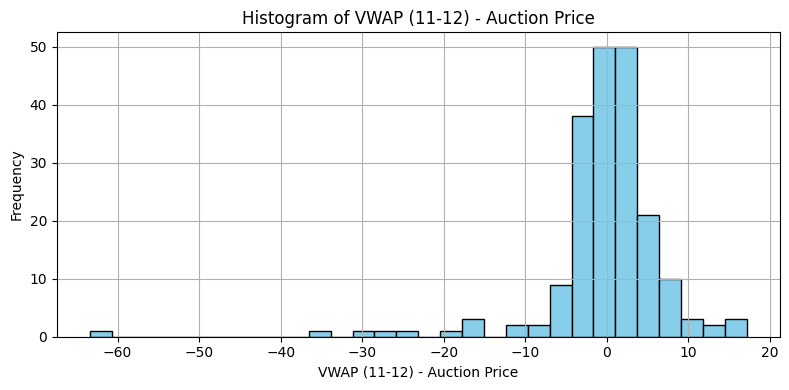

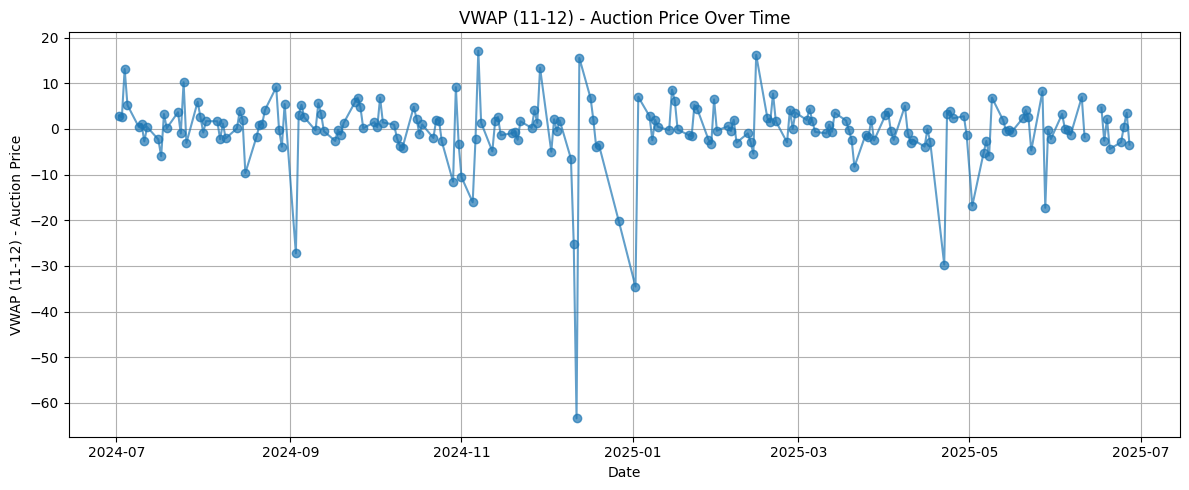

<Figure size 800x400 with 0 Axes>

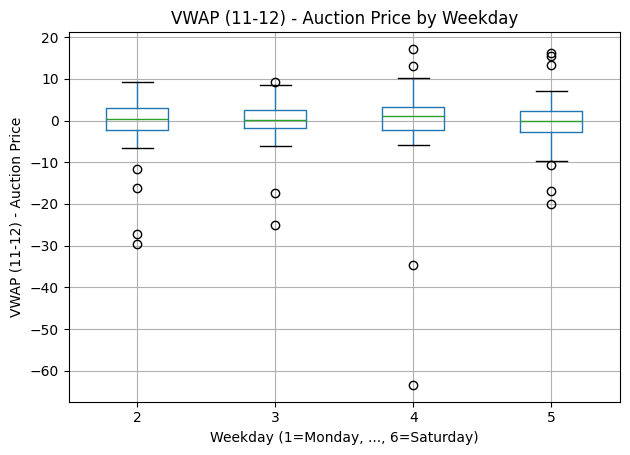

Mean and Std of VWAP (11-12) - Auction Price by Weekday:


,mean,std,count
weekday,,,
2,-0.812097,7.336485,50
3,0.056436,5.397820,50
4,-0.462679,11.450963,49
5,-0.142561,6.435090,50


In [30]:
# Calculate the difference
if 'vwap_11_to_12' in df.columns and 'auction_price' in df.columns:
    df['diff_vwap_auction'] = df['vwap_11_to_12'] - df['auction_price']
else:
    raise ValueError('Required columns not found in DataFrame.')

# Basic statistics
stats = df['diff_vwap_auction'].describe()
percentiles = df['diff_vwap_auction'].quantile([0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print('Basic statistics for VWAP (11-12) - Auction Price:')
print(stats)
print('\nPercentiles:')
print(percentiles)

# Histogram
plt.figure(figsize=(8,4))
plt.hist(df['diff_vwap_auction'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of VWAP (11-12) - Auction Price')
plt.xlabel('VWAP (11-12) - Auction Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Time series plot
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['diff_vwap_auction'], marker='o', linestyle='-', alpha=0.7)
plt.title('VWAP (11-12) - Auction Price Over Time')
plt.xlabel('Date')
plt.ylabel('VWAP (11-12) - Auction Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot by weekday
plt.figure(figsize=(8,4))
df.boxplot(column='diff_vwap_auction', by='weekday', grid=True)
plt.title('VWAP (11-12) - Auction Price by Weekday')
plt.suptitle('')
plt.xlabel('Weekday (1=Monday, ..., 6=Saturday)')
plt.ylabel('VWAP (11-12) - Auction Price')
plt.tight_layout()
plt.show()

# Mean and std by weekday
weekday_stats = df.groupby('weekday')['diff_vwap_auction'].agg(['mean','std','count'])
print('Mean and Std of VWAP (11-12) - Auction Price by Weekday:')
display(weekday_stats)

# Putting things together and exporting

In [31]:
df_dem1['datetime']=pd.to_datetime(df_dem1['datetime'])
df_dem1['date']=pd.to_datetime(df_dem1['datetime'].apply(lambda x: x.date()))

In [32]:
df_out=df_dem1.merge(df, how='left', on='date').dropna(subset='auction_price')
df_out=df_out[df_out['datetime'].apply(lambda x: x.hour>10 and  x.hour<14)]

In [33]:
df_out.to_csv('df_modelling_dew1.csv')